In [53]:
import plt
from PIL import Image
import pytesseract

pytesseract.pytesseract.tesseract_cmd = r"D:\Apps\Tesseract\tesseract.exe"

def text_from_image(image_path):

    img = Image.open(image_path)
    text = pytesseract.image_to_string(img)
    return text

print(text_from_image("images/ocr.png"))
print(text_from_image("images/test1.png"))
print(text_from_image("images/test2.jpeg"))
print(text_from_image("images/chestie.png"))

Optical

haracter

Recognition


‘ Se es
heen dyn fe sobtvarra

4EMELOR 22


This is a lot of 12 point text to test the
ocr code and see if it works on all types
of file format.

The quick brown dog jumped over the
lazy fox. The quick brown dog jumped
over the lazy fox. The quick brown dog
jumped over the lazy fox. The quick
brown dog jumped over the lazy fox.



In [42]:
import jellyfish

def levenshtein(a, b):
    n, m = len(a), len(b)
    dp = [[0]*(m+1) for _ in range(n+1)]

    for i in range(n+1):
        dp[i][0] = i
    for j in range(m+1):
        dp[0][j] = j

    for i in range(1,n+1):
        for j in range(1,m+1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i][j] = min(
                dp[i-1][j] + 1,
                dp[i][j-1] + 1,
                dp[i-1][j-1] + cost
            )

    return dp[n][m]

def word_error_rate_lev(ref, hyp):
    ref_words = ref.split()
    hyp_words = hyp.split()
    return levenshtein(ref_words, hyp_words) / len(ref_words)

def cer_jw(ref, hyp):
    ref = ref.strip()
    hyp = hyp.strip()
    similarity = jellyfish.jaro_winkler_similarity(ref, hyp)
    return 1 - similarity

def wer_jw(ref, hyp):
    ref_words = " ".join(ref.strip().split())
    hyp_words = " ".join(hyp.strip().split())
    similarity = jellyfish.jaro_winkler_similarity(ref_words, hyp_words)
    return 1 - similarity

def normalize(text):
    return " ".join(text.lower().split())

In [ ]:
ocr_text = "Optical Character Recognition"
test1_text = "Google Cloud Platform"
test2_text = "Succes in rezolvarea tEMELOR la LABORAtoarele de Inteligență Artificială"
chestie_text = "This is a lot of 12 point text to test the ocr code and see if it works on all types of file format.The quick brown dog jumped over the lazy fox. The quick brown dog jumped over the lazy fox. The quick brown dog jumped over the lazy fox."
ocr_text_pred = text_from_image("images/ocr.png")
test1_text_pred = text_from_image("images/test1.png")
test2_text_pred = text_from_image("images/test2.jpeg")
chestie_text_pred = text_from_image("images/chestie.png")

In [43]:
cer1 = levenshtein(ocr_text, normalize(ocr_text_pred)) / len(ocr_text)
cer2 = levenshtein(test1_text, normalize(test1_text_pred)) / len(test1_text)
cer3 = levenshtein(test2_text, normalize(test2_text_pred)) / len(test2_text)
cer4 = cer_jw(ocr_text, ocr_text_pred)
cer5 = cer_jw(test1_text, test1_text_pred)
cer6 = cer_jw(test2_text, test2_text_pred)

print("CER1:", cer1)
print("CER2:", cer2)
print("CER3:", cer3)
print("CER4:", cer4)
print("CER5:", cer5)
print("CER6:", cer6)


CER1: 0.10344827586206896
CER2: 1.0
CER3: 0.7777777777777778
CER4: 0.04735632183908045
CER5: 1.0
CER6: 0.446060337040152


In [44]:
wer1 = word_error_rate_lev(ocr_text, ocr_text_pred)
wer2 = word_error_rate_lev(test1_text, test1_text_pred)
wer3 = word_error_rate_lev(test2_text, test2_text_pred)
wer4 = wer_jw(ocr_text, ocr_text_pred)
wer5 = wer_jw(test1_text, test1_text_pred)
wer6 = wer_jw(test2_text, test2_text_pred)

print("WER1:", wer1)
print("WER2:", wer2)
print("WER3:", wer3)
print("WER4:", wer4)
print("WER5:", wer5)
print("WER6:", wer6)

WER1: 0.3333333333333333
WER2: 1.0
WER3: 1.0
WER4: 0.006896551724137945
WER5: 1.0
WER6: 0.40459976105137396


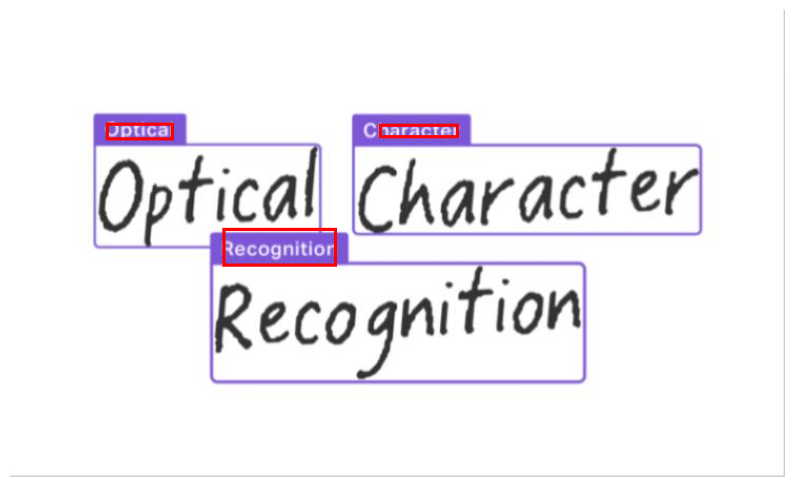

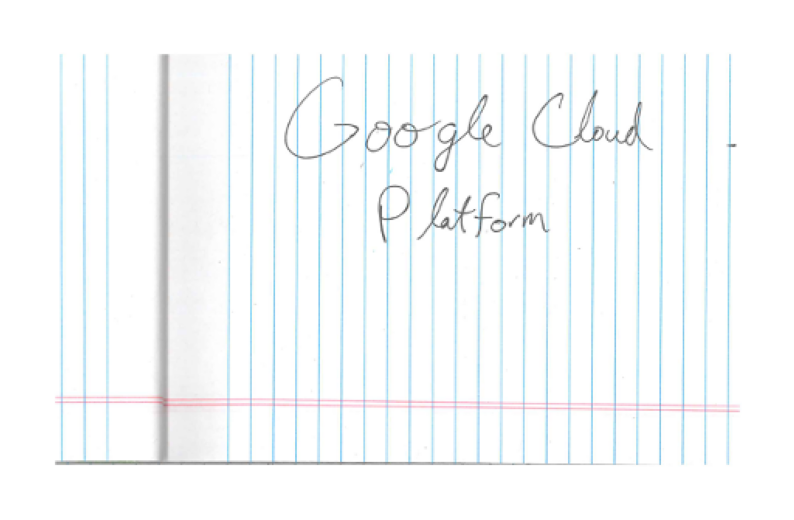

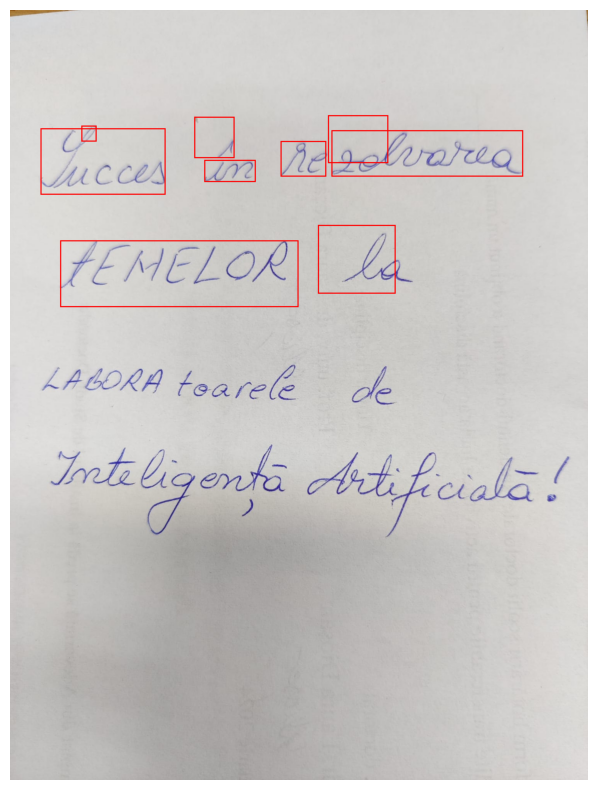

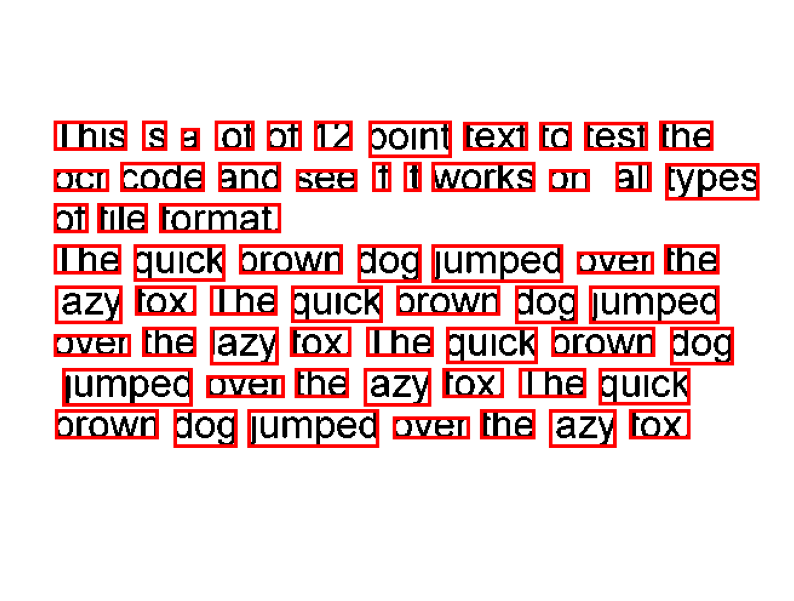

In [54]:
from PIL import ImageDraw
from pytesseract import Output
import matplotlib.pyplot as plt

def get_location_of_text_file(image_path):
    img = Image.open(image_path)
    data = pytesseract.image_to_data(img, output_type=Output.DICT)
    locations = []
    n_boxes = len(data['text'])
    for i in range(n_boxes):
        text = data['text'][i].strip()
        if text != "":
            x, y, w, h = data['left'][i], data['top'][i], data['width'][i], data['height'][i]
            locations.append((x, y, x + w, y + h))
    return locations


def image_with_box_surrounding_text(image_path):
    locations = get_location_of_text_file(image_path)
    image = Image.open(image_path)
    draw = ImageDraw.Draw(image)

    for location in locations:
        x1, y1, x2, y2 = location
        draw.rectangle([x1, y1, x2, y2], outline=(255, 0, 0), width=3)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

image_with_box_surrounding_text('images/ocr.png')
image_with_box_surrounding_text('images/test1.png')
image_with_box_surrounding_text('images/test2.jpeg')
image_with_box_surrounding_text('images/chestie.png')


In [49]:
import numpy as np

def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter_area = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = (box1[2]-box1[0])*(box1[3]-box1[1])
    box2_area = (box2[2]-box2[0])*(box2[3]-box2[1])
    union = box1_area + box2_area - inter_area
    if union == 0:
        return 0
    return inter_area / union

def quality_of_localization(image_path, actual_location):
    locations = get_location_of_text_file(image_path)
    ious = []

    min_len = min(len(actual_location), len(locations))
    for i in range(min_len):
        ious.append(calculate_iou(actual_location[i], locations[i]))

    for _ in range(len(actual_location) - min_len):
        ious.append(0)
    for _ in range(len(locations) - min_len):
        ious.append(0)

    return np.mean(ious)

In [58]:
print(quality_of_localization('images/test1.png', [[177,44,417,97],[234,112,350,151]]))
print(quality_of_localization('images/test2.jpeg', [[64,300,1345,469],[119,580,1065,726],[81,908,1025,1031],[106,1128,1467,1317]]))
print(quality_of_localization('images/chestie.png', [(36, 91, 97, 116), (108, 92, 130, 116), (141, 99, 155, 116), (168, 93, 202, 117), (212, 92, 241, 115), (252, 92, 282, 116), (296, 92, 365, 122), (374, 94, 428, 116), (437, 93, 462, 116), (474, 93, 527, 117), (536, 92, 579, 116), (36, 133, 81, 149), (91, 126, 161, 151), (173, 126, 223, 150), (236, 133, 286, 150), (299, 126, 315, 150), (325, 126, 339, 149), (348, 125, 433, 151), (445, 132, 479, 150), (500, 127, 529, 150), (541, 128, 618, 157), (36, 160, 65, 184), (72, 160, 113, 184), (124, 160, 222, 184), (36, 193, 91, 218), (103, 194, 176, 224), (189, 194, 274, 217), (288, 194, 338, 224), (348, 194, 456, 226), (468, 200, 532, 218), (540, 195, 585, 218), (37, 228, 92, 258), (104, 228, 153, 252), (165, 228, 221, 253), (233, 228, 307, 258), (319, 228, 404, 253), (418, 228, 468, 259), (478, 228, 585, 260), (36, 268, 100, 286), (110, 263, 153, 286), (165, 262, 222, 292), (231, 262, 280, 286), (294, 262, 350, 286), (360, 263, 435, 292), (448, 262, 532, 287), (545, 262, 598, 293), (44, 296, 150, 327), (162, 303, 225, 321), (235, 296, 280, 321), (292, 296, 348, 327), (357, 296, 408, 320), (420, 296, 474, 320), (487, 296, 561, 327), (37, 330, 123, 354), (135, 330, 188, 362), (196, 330, 304, 362), (316, 336, 380, 354), (388, 330, 434, 354), (445, 330, 501, 361), (511, 330, 561, 355)]))



0.0
0.0008206729518204928
0.9582572974604263
